In [1]:
from funda import Funda
import polars as pl
import seaborn as sns
import numpy as np
from dolcestat.optimization.gradient_descent import GradientDescent
from dolcestat.optimization.visualizers import GradientDescentVisualizer
from dolcestat.preprocessing import DolceSet

In [2]:
def get_listings_df_from_listings_list(listings_list):
    
    listings_dict = {
        'id': [],
        'offering_type': [],
        'city': [],
        'street_name': [],
        'postcode': [],
        'living_area': [],
        'total_area': [],
        'property_type': [],
        'construction_year': [],
        'rooms': [],
        'bedrooms': [],
        'energy_label': [],
        'price_actual': [],
        'price_min': [],
        'price_max': [],
        'publication_date': []
    }

    for listing in listings_list:
        listings_dict['id'].append(listing.id)
        listings_dict['offering_type'].append(listing.offering_type)
        listings_dict['city'].append(listing.city)
        listings_dict['street_name'].append(listing.address.street_name)
        listings_dict['postcode'].append(listing.address.postcode)
        listings_dict['living_area'].append(listing.areas.living)
        listings_dict['total_area'].append(listing.areas.plot)
        listings_dict['property_type'].append(listing.property_details.object_type)
        listings_dict['construction_year'].append(listing.property_details.construction_year)
        listings_dict['rooms'].append(listing.rooms.total)
        listings_dict['bedrooms'].append(listing.rooms.bedrooms)
        listings_dict['energy_label'].append(listing.energy_label)
        listings_dict['price_actual'].append(listing.price.amount)
        listings_dict['price_min'].append(listing.price.range_min)
        listings_dict['price_max'].append(listing.price.range_max)
        listings_dict['publication_date'].append(listing.publication_date)

    return pl.DataFrame(listings_dict)

In [3]:
with Funda() as client:
    listings = list(client.iter_search('breda', max_pages=5))

In [4]:
listings_df = get_listings_df_from_listings_list(listings).filter(pl.col('offering_type') == 'buy')
listings_df

id,offering_type,city,street_name,postcode,living_area,total_area,property_type,construction_year,rooms,bedrooms,energy_label,price_actual,price_min,price_max,publication_date
str,str,str,str,str,i64,i64,str,null,i64,i64,str,i64,i64,i64,str
"""80843319""","""buy""","""Breda""","""Lage Kant""","""4817GG""",88,135,"""house""",null,4,3,"""B""",385000,385000,385000,"""2026-06-07T09:00:01.8591521+02…"
"""44489526""","""buy""","""Breda""","""Coulissen""","""4811DX""",111,null,"""apartment""",null,3,2,"""A""",595000,595000,595000,"""2026-06-06T06:00:05.2506547+02…"
"""44489525""","""buy""","""Breda""","""Bisschopshoeve""","""4817PW""",121,234,"""house""",null,6,4,"""C""",450000,450000,450000,"""2026-06-05T22:10:11.2649983+02…"
"""44489596""","""buy""","""Breda""","""Heksenkring""","""4823JS""",251,254,"""house""",null,8,6,"""A""",795000,795000,795000,"""2026-06-05T20:32:49.1141442+02…"
"""44488690""","""buy""","""Breda""","""Moleneindstraat""","""4817BM""",104,364,"""house""",null,4,3,"""C""",469000,469000,469000,"""2026-06-05T15:12:34.5927766+02…"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""44465229""","""buy""","""Breda""","""Wisentstraat""","""4817LZ""",106,105,"""house""",null,4,3,"""A""",395000,395000,395000,"""2026-05-21T14:49:55.9647296+02…"
"""44465923""","""buy""","""Breda""","""Groene Woud""","""4834BA""",89,null,"""apartment""",null,3,2,"""A""",460000,460000,460000,"""2026-05-21T12:49:33.4741554+02…"
"""80829095""","""buy""","""Breda""","""Haagweg""","""4812XE""",110,169,"""house""",null,4,3,"""C""",535000,535000,535000,"""2026-05-21T11:41:02.8828974+02…"


<Axes: xlabel='living_area', ylabel='price_actual'>

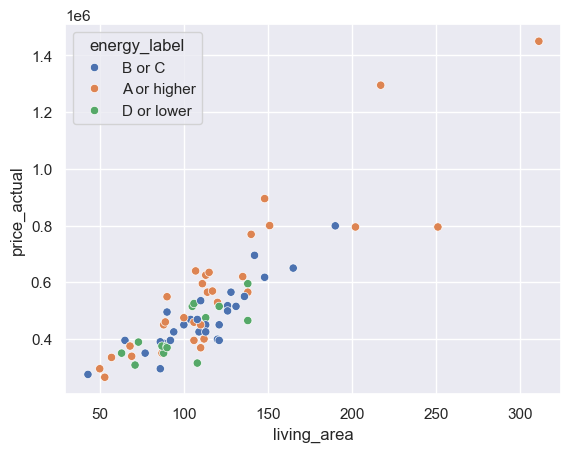

In [5]:
sns.set_theme()
upd_df = listings_df.with_columns(
    pl.when(pl.col("energy_label").is_in(["A", "A+", "A++", "A+++"]))
    .then(pl.lit("A or higher"))
    .when(pl.col("energy_label").is_in(["B", "C"]))
    .then(pl.lit("B or C"))
    .when(pl.col("energy_label").is_in(["D", "E", "F", "G"]))
    .then(pl.lit("D or lower"))
    .otherwise(pl.col("energy_label"))
    .alias("energy_label")
)
sns.scatterplot(
    data=upd_df.to_pandas(),
    x='living_area', 
    y='price_actual',
    hue='energy_label'
    )

In [6]:
# Prepare data for gradient descent
# 1. Reduce energy_label to 3 categories
df_for_gd = listings_df.with_columns(
    pl.when(pl.col("energy_label").is_in(["A", "A+", "A++", "A+++"]))
    .then(pl.lit('High'))
    .when(pl.col("energy_label").is_in(["B", "C"]))
    .then(pl.lit('Medium'))
    .when(pl.col("energy_label").is_in(["D", "E", "F", "G"]))
    .then(pl.lit('Low'))
    .otherwise(pl.lit(None))
    .alias("energy_label")
)

# 2. Initialize DolceSet
ds = DolceSet()
ds.load_from_polars_dataframe(df_for_gd, target_col='price_actual')

# 3. Select only relevant columns
ds.filter_features(['living_area', 'energy_label'])

# # 3. One-hot encode energy_label
ds.one_hot_encode('energy_label')

# 4. Normalize price and living_area
ds.scale(column_name='living_area', scaling_strategy='standardize')

In [7]:
gd = GradientDescent(data=ds, loss_function='mse', n_iters=2000)
gd.fit()

<Axes: title={'center': 'Loss (MSE)'}, xlabel='Iteration', ylabel='Loss'>

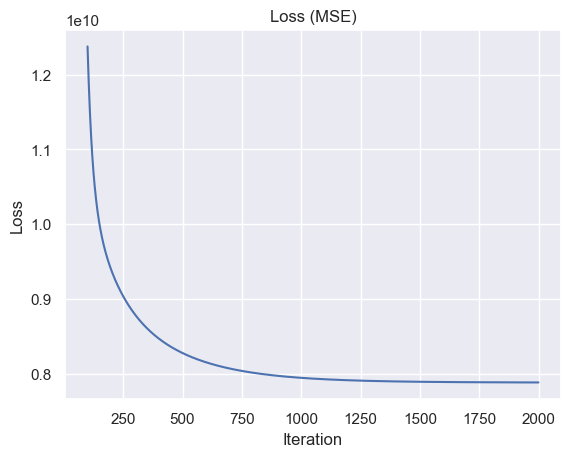

In [8]:
gdv = GradientDescentVisualizer(gd)
gdv.plot_loss(from_iter=100)

### With momentum

The same fit, now with **Polyak** and **Nesterov** momentum (`momentum_rate=0.9`). Momentum
carries part of the previous step into the next update, which can speed up convergence.

In [ ]:
gd_polyak = GradientDescent(data=ds, loss_function='mse', n_iters=2000,
                            momentum_type='polyak', momentum_rate=0.9)
gd_polyak.fit()

gd_nesterov = GradientDescent(data=ds, loss_function='mse', n_iters=2000,
                              momentum_type='nesterov', momentum_rate=0.9)
gd_nesterov.fit()

gdv_momentum = GradientDescentVisualizer([gd, gd_polyak, gd_nesterov])
ax = gdv_momentum.plot_loss(from_iter=100)
ax.legend(['none', 'polyak', 'nesterov'], title='momentum')

In [9]:
ds.get_colnames()

['energy_label_High', 'energy_label_Low', 'living_area']

In [10]:
ds.scaling_info

{'scaled': True,
 'details': [{'strategy': 'standardize',
   'columns': ['living_area'],
   'stats': {'mean': {'living_area': 113.41333333333333},
    'std': {'living_area': 42.50917018185076}}}]}

In [13]:
# Try prediction: what is the value of a 70mq house of energy label B/C?

# 1. Create DolceSet obj
test_ds = DolceSet()
test_ds.load_from_dict({
    'energy_label_High': [0],
    'energy_label_Low':[0],
    'living_area': [70]
})

# 2. Scale based on ds scaling
mean = ds.scaling_info['details'][0]['stats']['mean']['living_area']
std = mean = ds.scaling_info['details'][0]['stats']['std']['living_area']

test_ds.scale(
    column_name='living_area',
    scaling_strategy='standardize',
    mean = {'living_area': mean},
    std = {'living_area': std}
    )

# 3. Predict
gd.predict(test_ds)

array([589224.11605877])